# Fraud Detection — EDA
IEEE-CIS Fraud Detection dataset (`train_transaction.csv` + `train_identity.csv`)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
df_trans = pd.read_csv('../data/raw/train_transaction.csv')
df_id = pd.read_csv('../data/raw/train_identity.csv')
print(df_trans.head())


   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ... V330  V331  V332  V333  V334 V335  \
0    NaN  150.0    discover  142.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
1  404.0  150.0  mastercard  102.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
2  490.0  150.0        visa  166.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
3  567.0  150.0  mastercard  117.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
4  514.0  150.0  mastercard  102.0  ...  0.0   0.0   0.0   0.0   0.0  0.0   

  V336  V337  V338  V339  
0  NaN   NaN   NaN   NaN  
1  NaN   NaN   NaN  

In [4]:
df_id.duplicated().sum()

0

In [5]:
print(df_id.head())


   TransactionID  id_01     id_02  id_03  id_04  id_05  id_06  id_07  id_08  \
0        2987004    0.0   70787.0    NaN    NaN    NaN    NaN    NaN    NaN   
1        2987008   -5.0   98945.0    NaN    NaN    0.0   -5.0    NaN    NaN   
2        2987010   -5.0  191631.0    0.0    0.0    0.0    0.0    NaN    NaN   
3        2987011   -5.0  221832.0    NaN    NaN    0.0   -6.0    NaN    NaN   
4        2987016    0.0    7460.0    0.0    0.0    1.0    0.0    NaN    NaN   

   id_09  ...                id_31  id_32      id_33           id_34  id_35  \
0    NaN  ...  samsung browser 6.2   32.0  2220x1080  match_status:2      T   
1    NaN  ...   mobile safari 11.0   32.0   1334x750  match_status:1      T   
2    0.0  ...          chrome 62.0    NaN        NaN             NaN      F   
3    NaN  ...          chrome 62.0    NaN        NaN             NaN      F   
4    0.0  ...          chrome 62.0   24.0   1280x800  match_status:2      T   

  id_36 id_37  id_38  DeviceType                  

In [6]:
print(df_id.shape)
print(df_trans.shape)

(144233, 41)
(590540, 394)


In [7]:
merged = pd.merge(df_trans, df_id, on='TransactionID', how='left')
print(merged.shape)

(590540, 434)


In [27]:
print(df_trans.columns.tolist())

['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V

### Exploring Value counts of target variable ( to see class dist )

In [28]:
df_trans["isFraud"].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

3.5% fraud rate in data,  
This is your justification for everything imbalance-related later: why you'll use scale_pos_weight in XGBoost, why accuracy is a useless metric, why you'll evaluate on AUC-ROC and precision-recall instead

### NULL analysis of each col (of top 20 cols in merged with most nulls)

In [29]:
merged.isnull().sum().sort_values(ascending=False).head(20)

id_24    585793
id_25    585408
id_07    585385
id_08    585385
id_21    585381
id_26    585377
id_27    585371
id_23    585371
id_22    585371
dist2    552913
D7       551623
id_18    545427
D13      528588
D14      528353
D12      525823
id_03    524216
id_04    524216
D6       517353
id_33    517251
id_10    515614
dtype: int64

Most of the mostly null are the id cols, (drop later since very high null counts, contain no meaninful data), 

Columns above ~90% null are candidates to drop before modeling

BUT ALSO
"Null" in identity columns doesn't mean bad data — it means no identity record existed for that transaction, which is itself informative



Also cant remove during EDA because what if a col is 85% null and the 15% rows that have values have a very high fraud rate. THIS might indicate presence of value for that col is linked to a fraud.



In [30]:
null_pct = merged.isnull().sum()/len(merged) * 100
print((null_pct>90).sum())
print((null_pct>50).sum())
print((null_pct>20).sum())

12
214
252


In [31]:
v_cols = [col for col in merged.columns if col.startswith('V')]
id_cols =  [c for c in merged.columns if c.startswith('id_') or c in ['DeviceType', 'DeviceInfo']]
trans_cols = [c for c in merged.columns if c not in id_cols + v_cols]
print(f"Number of transaction columns: {len(trans_cols)}")     
print(f"Number of identity columns: {len(id_cols)}")   
print(f"Number of V columns: {len(v_cols)}")    

Number of transaction columns: 55
Number of identity columns: 40
Number of V columns: 339


In [32]:
null_pct = merged[v_cols].isnull().sum()/len(merged) * 100
print((null_pct>90).sum())
print((null_pct>50).sum())
print((null_pct>20).sum())

0
159
188


In [33]:
null_pct = merged[id_cols].isnull().sum()/len(merged) * 100
print((null_pct>90).sum())
print((null_pct>50).sum())
print((null_pct>20).sum())

10
40
40


In [34]:
null_pct = merged[trans_cols].isnull().sum()/len(merged) * 100
print((null_pct>90).sum())
print((null_pct>50).sum())
print((null_pct>20).sum())

2
15
24


In [35]:
print(merged.columns.tolist())

['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V

### Moving onto analysing trasaction amounts now

In [36]:
merged['TransactionAmt'].describe()

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

Mean higher than median means right skew in transaction amounts

also since amounts range is so wide, we likely need log transforms in distance based models later
- also, extreme values (min and max) are likely signals for fraud indication (0.25 is like a small test amount  before fraud, high amount is like account takeover transactions)

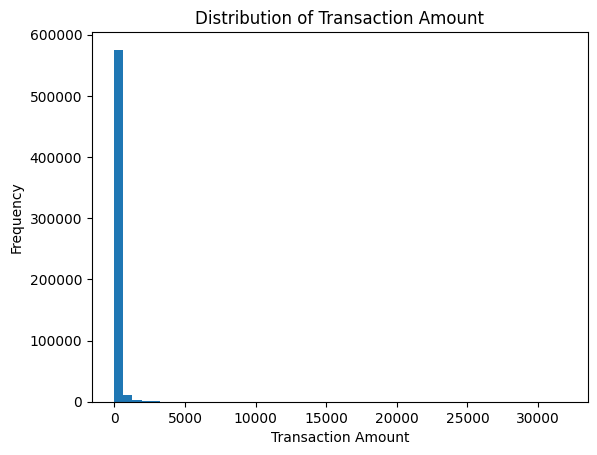

In [37]:
plt.hist(merged['TransactionAmt'], bins=50)
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Transaction Amount')
plt.show()

Now we'll plot a log transformed col plot : How it helps:
Log compression shrinks large values much more than small ones. Concretely:

$1 → log(1) = 0
$10 → log(10) = 2.3
$100 → log(100) = 4.6
$1000 → log(1000) = 6.9
$31,937 → log(31,937) = 10.4

Notice the jump from $1 to $1,000 is only 6.9 units on the log scale, but 999 units on the raw scale. **The distribution gets spread out where the data actually is, and the extreme values stop dominating.**
The result is usually a much more bell-shaped, readable distribution — and for models that care about scale, the feature becomes much more useful.

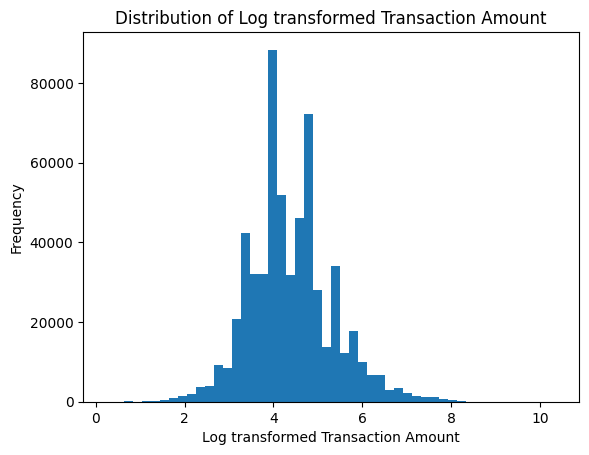

In [38]:
plt.hist(np.log1p(merged['TransactionAmt']), bins=50)
plt.xlabel('Log transformed Transaction Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Log transformed Transaction Amount')
plt.show()

Multimodal shape (many peaks) at certain values of the log transformed amount(correspong to actual $) is interesting, it might indicate fraud patterns of commonly used transaction amounts: eg: $25, $50 etc.

Now, lets plot fraud vs non fraud transaction amounts separately

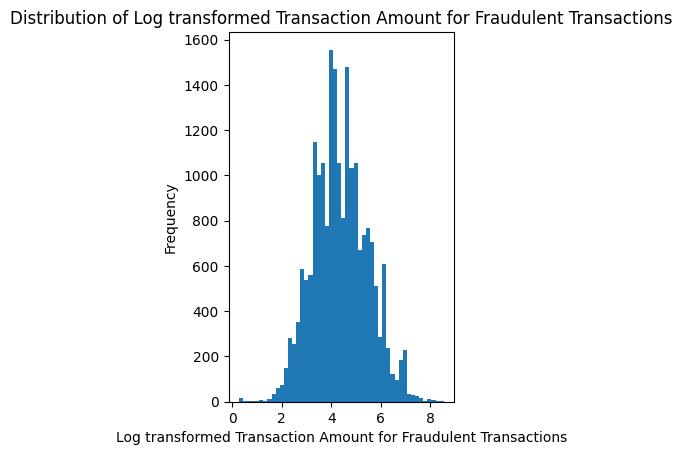

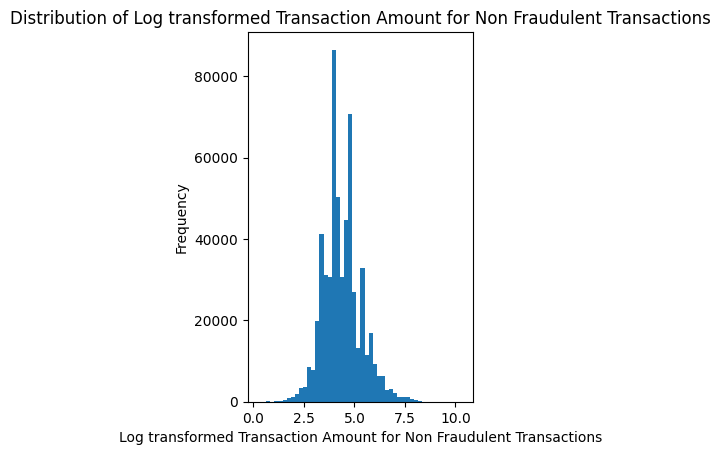

In [39]:
fraud_dataset = np.log1p(merged[merged['isFraud'] == 1]['TransactionAmt'])
plt.subplot(1,2,1)
plt.hist(fraud_dataset, bins=50)
plt.xlabel('Log transformed Transaction Amount for Fraudulent Transactions')
plt.ylabel('Frequency')
plt.title('Distribution of Log transformed Transaction Amount for Fraudulent Transactions')
plt.show()

non_fraud_dataset = np.log1p(merged[merged['isFraud'] == 0]['TransactionAmt'])
plt.subplot(1,2,2)
plt.hist(non_fraud_dataset, bins=50)
plt.xlabel('Log transformed Transaction Amount for Non Fraudulent Transactions')
plt.ylabel('Frequency')
plt.title('Distribution of Log transformed Transaction Amount for Non Fraudulent Transactions')
plt.show()

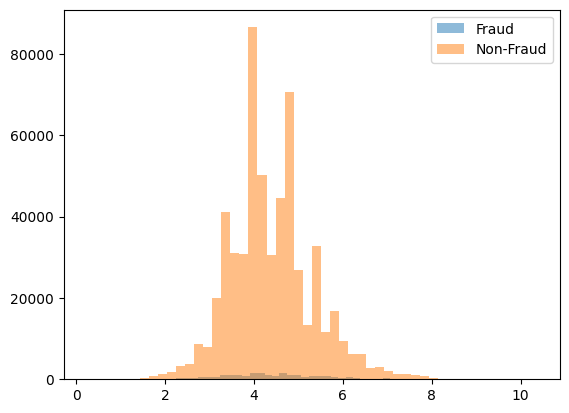

In [40]:
plt.hist(fraud_dataset, bins=50, alpha=0.5, label='Fraud')
plt.hist(non_fraud_dataset, bins=50, alpha=0.5, label='Non-Fraud')
plt.legend()

these 2 overlap because matplotlib keeps adding to the same current active figure until its explictly told to render (plt.show()). so both plthist calls draw onto the same axes by default

also since y (freq counts) of non fraud in each bin is too high as compared to the fraud dataset, its barely visible.

instead (fraud has 20k transactions for ex, but non fraud has 570k, so on yaxis instead of raw counts we want to shift them to the same scale and PLOT **DENSITY**: which is saying how many transactinos fall into this bin. THEN WE plot the **what propoertion of this class falls into this bin**. THey both sum to 1 so on the same scale)

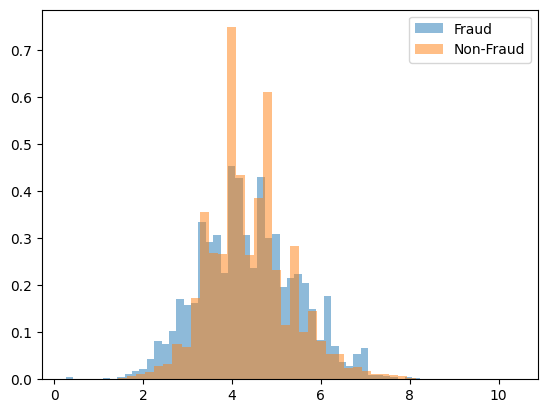

In [41]:
plt.hist(fraud_dataset, bins=50, alpha=0.5, label='Fraud', density=True)
plt.hist(non_fraud_dataset, bins=50, alpha=0.5, label='Non-Fraud', density=True)
plt.legend()

Fraud transactions show higher density in tails, both small amounts and mid range around 4.505 on log scale. Non fraud is more tightly concentrated around the $50-100 range with sharper peaks, suggesting more routine behaviour. This confirms that the transaction amt is useful **SINCE BOTH PLOTS ARE DIFFERENT ENOUGH**\
*EDA FINDING No.1*

### Moving onto TransactionDT: Exploring timedelta  : seconds elapsed since some reference point, So row having Trasnaction DT = 86400 is this no. of seconds after reference point

<Axes: xlabel='TransactionDT'>

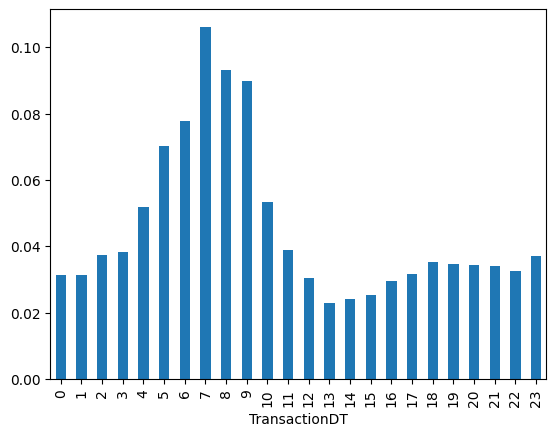

In [45]:
hour = (merged['TransactionDT'] // 3600) % 24

merged.groupby(hour)['isFraud'].mean().plot(kind='bar')


<Axes: xlabel='TransactionDT'>

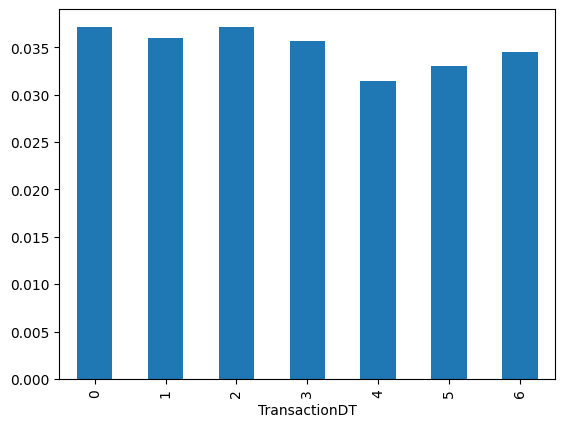

In [46]:
day_of_the_week = (merged['TransactionDT'] // (3600*24)) % 7
merged.groupby(day_of_the_week)['isFraud'].mean().plot(kind='bar')


So we see that for the hour of day, the fraud rate peaks between hours 4-9 (3x-5x). STRONG SIGNAL of FRAUD

But Fraud rate for day of the week is flat for all the days: Can probably drop.

In [56]:
print(merged.select_dtypes(include='object').columns.tolist())

['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


# Categorical Columns

for a categorical col, the 2 most useful things to know are:
- what are the possible values and how common is each one?
- what is the fraud rate for each value?

In [62]:
merged.groupby('ProductCD')['isFraud'].mean()

ProductCD
C    0.116873
H    0.047662
R    0.037826
S    0.058996
W    0.020399
Name: isFraud, dtype: float64

ProductCD category C has disproportionately high fraud rate (~12%) vs category W (~2%) — strong categorical signal.

In [63]:
merged.groupby('card4')['isFraud'].mean()

card4
american express    0.028698
discover            0.077282
mastercard          0.034331
visa                0.034756
Name: isFraud, dtype: float64

In [64]:
merged.groupby('card6')['isFraud'].mean()

card6
charge card        0.000000
credit             0.066785
debit              0.024263
debit or credit    0.000000
Name: isFraud, dtype: float64

In [65]:
merged['card6'].value_counts()

card6
debit              439938
credit             148986
debit or credit        30
charge card            15
Name: count, dtype: int64

In [66]:
merged['P_emaildomain'].value_counts()

P_emaildomain
gmail.com           228355
yahoo.com           100934
hotmail.com          45250
anonymous.com        36998
aol.com              28289
comcast.net           7888
icloud.com            6267
outlook.com           5096
msn.com               4092
att.net               4033
live.com              3041
sbcglobal.net         2970
verizon.net           2705
ymail.com             2396
bellsouth.net         1909
yahoo.com.mx          1543
me.com                1522
cox.net               1393
optonline.net         1011
charter.net            816
live.com.mx            749
rocketmail.com         664
mail.com               559
earthlink.net          514
gmail                  496
outlook.es             438
mac.com                436
juno.com               322
aim.com                315
hotmail.es             305
roadrunner.com         305
windstream.net         305
hotmail.fr             295
frontier.com           280
embarqmail.com         260
web.de                 240
netzero.com   

Since P_emaildomain has high cardinality, we'll just look at top 10 most frequent domains(to see what normal looks like - baseline) and top 10 highest fraud rate domains (to see what suspicious looks like)

In [78]:
#top 10 highest fraud rate email domains
res1=merged.groupby('P_emaildomain')['isFraud'].mean().sort_values(ascending=False).head(10)
res1

P_emaildomain
protonmail.com    0.407895
mail.com          0.189624
outlook.es        0.130137
aim.com           0.126984
outlook.com       0.094584
hotmail.es        0.065574
live.com.mx       0.054740
hotmail.com       0.052950
gmail.com         0.043542
yahoo.fr          0.034965
Name: isFraud, dtype: float64

In [79]:
res2=merged[merged['P_emaildomain'].isin(merged['P_emaildomain'].value_counts().head(10).index)].groupby('P_emaildomain')['isFraud'].mean()
res2

P_emaildomain
anonymous.com    0.023217
aol.com          0.021811
att.net          0.007439
comcast.net      0.031187
gmail.com        0.043542
hotmail.com      0.052950
icloud.com       0.031434
msn.com          0.021994
outlook.com      0.094584
yahoo.com        0.022757
Name: isFraud, dtype: float64

Purchaser email  is a strong fraud signal - protonmail.com has 40% fraud rate vs gmail.com at 4$. Low-frequency, privacy focussed domains are disproportionately associated with fraud.

In [81]:
merged.groupby('R_emaildomain')['isFraud'].mean().sort_values(ascending=False).head(10)

R_emaildomain
protonmail.com    0.951220
mail.com          0.377049
netzero.net       0.222222
outlook.com       0.165138
outlook.es        0.131640
icloud.com        0.128755
gmail.com         0.119184
hotmail.com       0.077793
earthlink.net     0.075949
hotmail.es        0.068493
Name: isFraud, dtype: float64

In [82]:
merged[merged['R_emaildomain'].isin(merged['R_emaildomain'].value_counts().head(10).index)].groupby('R_emaildomain')['isFraud'].mean()

R_emaildomain
anonymous.com    0.029130
aol.com          0.034855
comcast.net      0.011589
gmail.com        0.119184
hotmail.com      0.077793
icloud.com       0.128755
msn.com          0.001174
outlook.com      0.165138
yahoo.com        0.051512
yahoo.com.mx     0.010610
Name: isFraud, dtype: float64

R_emaildomain is a stronger fraud signal than P_emaildomain — protonmail.com as recipient has 95% fraud rate. Recipient email domain likely reflects fraudster-controlled accounts.

Done with Categ cols now, 

we decide to do eda if
- col is interperetable
- col has relatively low variance
- likely to be a strong feature (business context)


so for this dataset: core trasaction cols: always analyze, time features always analyze, high cardinality cols: top N /bottom N only, rest do correlation analysis with target

"3.5% fraud rate — dataset is heavily imbalanced"\
"ProductCD category C has 6x higher fraud rate than W"\
"R_emaildomain protonmail = 95% fraud rate"\
"Fraud spikes during hours 4–9"



## V cols

Theres 339 of them but don't know each meaning because Vesta won't say what they are.



Only thing we can do is correlation analysis with the target.

In [94]:
v_cols_corr_head = merged[v_cols].corrwith(merged['isFraud']).abs().sort_values(ascending=False).head(10)
v_cols_corr_head

V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
dtype: float64

In [95]:
v_cols_corr_tail = merged[v_cols].corrwith(merged['isFraud']).abs().sort_values(ascending=False).tail(10)
v_cols_corr_tail

V210    0.000653
V216    0.000612
V88     0.000554
V305    0.000496
V334    0.000451
V299    0.000308
V135    0.000276
V137    0.000115
V319    0.000061
V136    0.000042
dtype: float64

We'll remove the less corr ones bcz they are noise. More features means more computation(training time). \
Also, risk of overfitting to noise\
also curse of dimensinoality: databecomes increasingly sparse. Useful patterns become hard to distinguish from random variation.\
Interpretability

In [96]:
top_v_cols = v_cols_corr_head.head(20).index.tolist()

*check for multicollinearity later (affects SHAP values)

In [99]:
merged[['card1','card2','card3','card5', 'card4', 'card6']].dtypes

card1      int64
card2    float64
card3    float64
card5    float64
card4     object
card6     object
dtype: object

In [100]:
merged[['card1','card2','card3','card5']].describe()

,card1,card2,card3,card5
count,590540.000000,581607.000000,588975.000000,586281.000000
mean,9898.734658,362.555488,153.194925,199.278897
std,4901.170153,157.793246,11.336444,41.244453
min,1000.000000,100.000000,100.000000,100.000000
25%,6019.000000,214.000000,150.000000,166.000000
50%,9678.000000,361.000000,150.000000,226.000000
75%,14184.000000,512.000000,150.000000,226.000000
max,18396.000000,600.000000,231.000000,237.000000


In [104]:
merged.groupby('isFraud')[['card1','card2','card3','card5']].mean()

,card1,card2,card3,card5
isFraud,,,,
0,9911.464381,362.453981,152.862034,199.542212
1,9547.654164,365.370850,162.368648,191.994328


But for numerical cols, fraud ratio(mean) isnt enough by its own. Because for some card, the values for fraud might be clustered around a specific value (strong indicator) still leading to the same fraction of Fraud values.

In [105]:
merged.groupby('isFraud')[['addr1','addr2']].mean()


,addr1,addr2
isFraud,,
0,290.643341,86.813620
1,294.317134,86.286024


addr1 and addr2 show minimal mean difference between fraud and non-fraud. addr2 is near-constant (87.0) — drop candidate.

In [109]:
numeric_trans_cols = merged[trans_cols].select_dtypes(include="number").columns.tolist()
numeric_trans_cols

['TransactionID',
 'isFraud',
 'TransactionDT',
 'TransactionAmt',
 'card1',
 'card2',
 'card3',
 'card5',
 'addr1',
 'addr2',
 'dist1',
 'dist2',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'C13',
 'C14',
 'D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'D6',
 'D7',
 'D8',
 'D9',
 'D10',
 'D11',
 'D12',
 'D13',
 'D14',
 'D15']

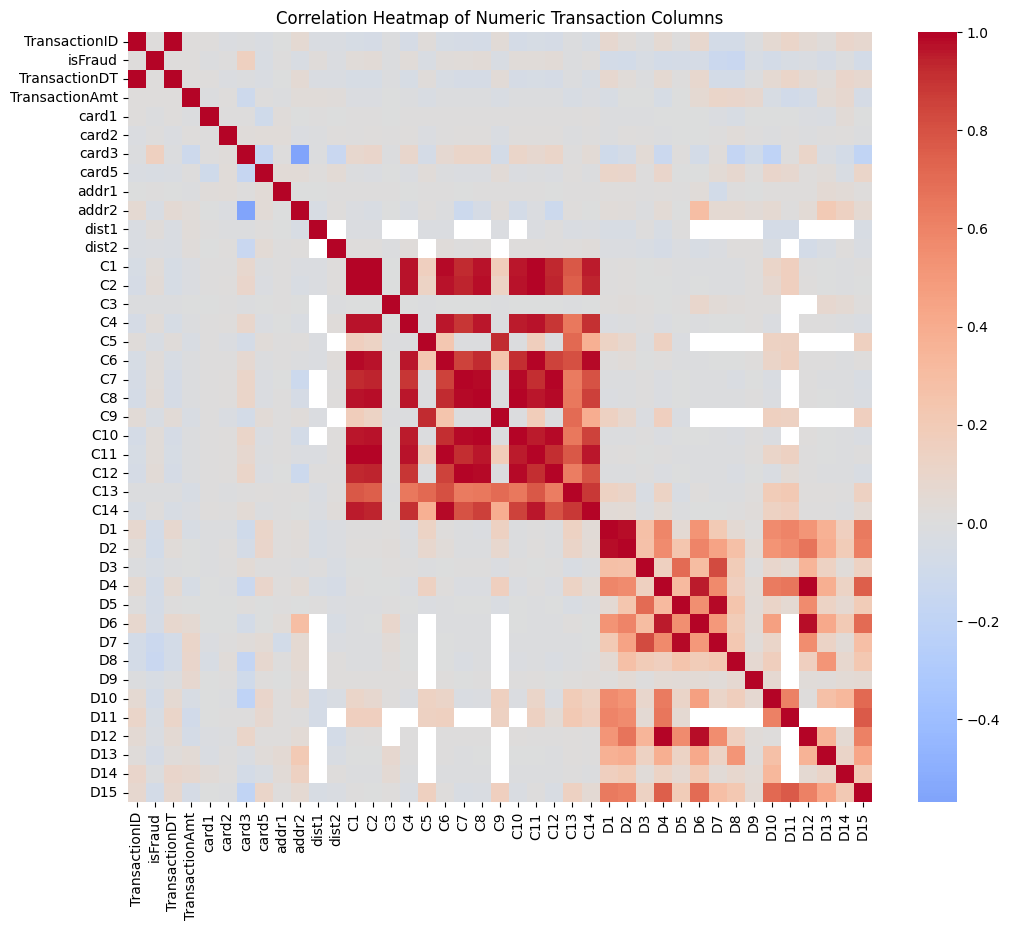

In [113]:
import seaborn as sns
corr = merged[numeric_trans_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Transaction Columns')
plt.show()  

- C cols cluster in the heatmap of corr above(indicate high multicollinearity, concern for logistic regression)
- D col same issue
- isFraud line is mostly light. So no singular feature has dominant linear relation with isFraud. Fraud signal is distributed and non linear, which is exactly why XGBoost wil outperform Logistic Regression here.
- White cells: NaN correlations(columns are too sparse to compute a reliable correlation)

So we found that one of our data assets was bigger than the other one so we joined left joint then we did some Nalan analysis and found out that a lot of the ID combs are really know and some of the columns are also now so it just indicates we might wanna drop it later on since spa stayed on and causes our not a good correlation indicator and analyzed transaction column. Now we found out that the distribution of the transaction one was highly right skewed so we not transformed it and found out some peaks and most of their transaction amounts populated between the 2 to 6 range and the peak and we compared the law transformed transaction amount histograms with the non-Frat and the fraudulent graphs for both we said there were way many more non-fraud transactions than the fraud transactions but the fraud transaction showed some high density in the tails so small amounts and large amount for transaction DT, which is like timed out since a reference point we saw that the fraud fraud column had higher ratios for fraud or more for transactions at 5 AM to 10 AM and there was no effect of the day of the week they moved onto critical columns. We saw that product see in product. TD had a higher fraud rate and then we also saw that for card for column there was not really indication. Maybe the Discover card had higher as compared to the others fraud and then we saw credit and debit card six column most of the product for email them when we saw high so we just got the top 10 highest fraud email dimensions and the top 10 most popular email them compared them. We saw that proton male at 40% fraudulent for a P or purchase or emailed them in and then the receiver emailed them and showed a high indication that proton mail as a receiver had a 95% frat and then some  columns have multicollionearity

Null analysis was vague — "a lot of ID columns are null" is not enough. The precise answer is: 10 identity columns are >90% null, missingness is structural not random (only 144k of 590k transactions have identity data), and null itself can be a signal worth keeping as a feature.
TransactionAmt tails — you said fraud had high density in tails but didn't articulate why that matters. The answer is: small amounts = card testing pattern, large amounts = account takeover pattern. That's the fraud behavior story.
Hour of day — you said 5–10am but the precise finding was hours 4–9 have ~3x higher fraud rate than midday hours. Be specific with numbers in interviews.
Email domain — good on protonmail numbers. But you missed the key insight: high frequency domains (gmail, yahoo) are actually safer, fraud concentrates in low frequency obscure domains. That's the counterintuitive finding worth highlighting.
Multicollinearity — you mentioned it at the end but didn't connect it to anything. The complete answer is: C columns cluster together, D columns cluster together, and this affects Logistic Regression more than XGBoost, which is part of why you chose XGBoost as primary model.




\
* Multicollinearity is why XG boost is chosen as primary model *

In [114]:
merged['has_identity'] = merged['id_01'].notna().astype(int)
merged.groupby('has_identity')['isFraud'].mean()

has_identity
0    0.020939
1    0.078470
Name: isFraud, dtype: float64

# EDA Summary — IEEE-CIS Fraud Detection

## Dataset Structure
Two files joined on TransactionID via left join — 590,540 transactions × 434 columns 
after merge. Left join chosen to preserve all transactions since ~60% have no identity 
record. Missing identity is structural, not a data quality issue.

## Class Imbalance
3.5% fraud rate (20,663 fraud vs 569,877 non-fraud). Justifies using AUPRC as primary 
metric, scale_pos_weight in XGBoost, and makes accuracy a useless metric.

## Missingness
- 10 identity columns >90% null — drop candidates
- 40/40 identity columns >50% null — structural, driven by sparse identity join
- 2 core transaction columns >90% null
- Missingness in identity columns is not random — "no identity record" is itself a signal
- Feature engineering idea: `has_identity` binary flag

## TransactionAmt
- Heavily right skewed (mean $135, median $68, max $31,937)
- Log transform reveals multimodal distribution with natural clusters around $50–$150
- Fraud shows higher density in both tails — small amounts (card testing pattern) and 
  mid-range peaks around log 4.5–5
- Extreme values are signal not noise in fraud detection

## TransactionDT
- Raw seconds from unknown reference point
- Engineered: hour of day, day of week
- Hour of day: fraud rate peaks 3x higher during hours 4–9 (victims asleep)
- Day of week: flat ~3.5% fraud rate across all 7 days — low predictive value, likely drop

## ProductCD
- Category C: ~12% fraud rate vs W at ~2% — 6x difference
- Strong categorical signal

## Card Features
- card4: Discover at 7.7% fraud vs Visa/Mastercard at ~3.4%
- card6: Credit at 6.7% fraud vs debit at 2.4% — higher limits more attractive to fraudsters
- card1–3, card5: <4% mean difference between fraud and non-fraud — low priority

## Email Domains
- P_emaildomain: protonmail.com at 40% fraud rate vs gmail.com at 4%
- High frequency domains are safer — fraud concentrates in low frequency, privacy-focused domains
- R_emaildomain: protonmail.com at 95% fraud rate — near deterministic signal
- Recipient email is stronger fraud signal than purchaser email
- Feature engineering idea: binary flag `is_protonmail_recipient`

## V-Columns
- Top correlated: V257 (0.38), V246 (0.37), V244 (0.36), V242 (0.36)
- Strong signals despite being anonymized
- Bottom correlated: V136, V319 near zero — drop candidates
- Top 20 V-columns flagged for feature selection

## addr Features
- addr2: near-constant at 87.0 — zero variance, drop candidate
- addr1: minimal mean difference between fraud and non-fraud — low priority

## Correlation Heatmap
- C columns (C1–C14): high correlation cluster — transaction count features
- D columns (D1–D15): separate cluster — timedelta features
- Multicollinearity within each group affects Logistic Regression more than XGBoost
- No single transaction feature dominates linear correlation with isFraud
- Fraud signal is distributed and non-linear — justifies XGBoost as primary model

## Key Feature Engineering Ideas (from EDA)
- Log transform TransactionAmt
- Engineer hour_of_day from TransactionDT (drop day_of_week)
- Binary flag: has_identity
- Binary flag: is_protonmail_recipient
- Drop addr2, near-zero V-columns, >90% null identity columns
- Target encode high cardinality categoricals (P/R emaildomain, ProductCD)

In [128]:
null_pct = merged.isnull().sum() / len(merged)
drop_candidates = null_pct[null_pct > 0.90].index.tolist()
print(drop_candidates)

['dist2', 'D7', 'id_07', 'id_08', 'id_18', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27']


In [130]:
v_cols_corr = merged[v_cols].corrwith(merged['isFraud']).abs()
low_signal_v_cols = v_cols_corr[v_cols_corr < 0.01].index.tolist()
print(len(low_signal_v_cols))
print(low_signal_v_cols)

81
['V1', 'V14', 'V25', 'V27', 'V28', 'V41', 'V65', 'V68', 'V88', 'V89', 'V95', 'V96', 'V97', 'V101', 'V102', 'V103', 'V104', 'V105', 'V106', 'V107', 'V126', 'V127', 'V128', 'V130', 'V132', 'V133', 'V134', 'V135', 'V136', 'V137', 'V175', 'V180', 'V183', 'V205', 'V206', 'V208', 'V210', 'V214', 'V215', 'V216', 'V223', 'V224', 'V225', 'V226', 'V240', 'V241', 'V264', 'V266', 'V267', 'V268', 'V269', 'V276', 'V279', 'V280', 'V285', 'V286', 'V293', 'V294', 'V295', 'V296', 'V297', 'V298', 'V299', 'V305', 'V306', 'V307', 'V308', 'V311', 'V316', 'V317', 'V318', 'V319', 'V320', 'V321', 'V325', 'V326', 'V327', 'V334', 'V335', 'V336', 'V337']


In [140]:
#ProductCD value types
print(merged['DeviceInfo'].value_counts())

DeviceInfo
Windows        47722
iOS Device     19782
MacOS          12573
Trident/7.0     7440
rv:11.0         1901
               ...  
LGMS345            1
verykool           1
XT1072             1
LG-H931            1
0PJA2              1
Name: count, Length: 1786, dtype: int64


In [141]:
merged.groupby('DeviceInfo')['isFraud'].mean().describe()

count    1786.000000
mean        0.083777
std         0.215578
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: isFraud, dtype: float64

In [142]:
#fraud rate by devicetype
merged.groupby('DeviceType')['isFraud'].mean().describe()

count    2.000000
mean     0.083438
std      0.025772
min      0.065215
25%      0.074327
50%      0.083438
75%      0.092550
max      0.101662
Name: isFraud, dtype: float64

In [19]:
merged["DeviceType"].notna

<bound method Series.notna of 0            NaN
1            NaN
2            NaN
3            NaN
4         mobile
           ...  
590535       NaN
590536       NaN
590537       NaN
590538       NaN
590539       NaN
Name: DeviceType, Length: 590540, dtype: object>

In [24]:
merged.dtypes.tolist()

[dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('float64'),
 dtype('O'),
 dtype('int64'),
 dtype('float64'),
 dtype('float64'),
 dtype('O'),
 dtype('float64'),
 dtype('O'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('O'),
 dtype('O'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('float64'),
 dtype('float64'),
 dtype('f

In [9]:
merged.select_dtypes(include='object').nunique().sort_values(ascending = False)

DeviceInfo       1786
id_33             260
id_31             130
id_30              75
R_emaildomain      60
P_emaildomain      59
ProductCD           5
id_34               4
card4               4
card6               4
id_15               3
id_23               3
M4                  3
M2                  2
DeviceType          2
id_38               2
id_37               2
id_36               2
id_35               2
M1                  2
M3                  2
id_29               2
id_27               2
id_16               2
id_12               2
M9                  2
M8                  2
M7                  2
M6                  2
M5                  2
id_28               2
dtype: int64

Ok so for dropping cols pretraining we keep these things in mind:
- 90% null (but create presence flags first)
- near zero variance ( but check if the rows for which value changes suggests fraud)
- Identifier columns (TransactionID — not a feature)
- Columns you've explicitly decided not to use (DeviceInfo, TransactionDT after extraction)


In [28]:
merged.select_dtypes(exclude='object').var().sort_values(ascending = True).iloc[20:40]

V113       0.005588
V108       0.006585
V112       0.007160
V110       0.009465
V114       0.012139
V109       0.016325
V116       0.018706
C3         0.022661
V46        0.027795
isFraud    0.033766
V25        0.034316
V8         0.034622
V115       0.036246
V286       0.036458
V26        0.043807
V141       0.046282
V66        0.046758
V9         0.051229
V123       0.052045
V47        0.053760
dtype: float64

In [ ]:
merged7

0         87.0
1         87.0
2         87.0
3         87.0
4         87.0
          ... 
590535    87.0
590536    87.0
590537    87.0
590538    87.0
590539    87.0
Name: addr2, Length: 590540, dtype: float64

In [31]:
merged["addr2"].value_counts()

addr2
87.0    520481
60.0      3084
96.0       638
32.0        91
65.0        82
         ...  
49.0         1
14.0         1
25.0         1
22.0         1
93.0         1
Name: count, Length: 74, dtype: int64

In [42]:
null_pct = merged.isnull().sum()/len(merged) * 100
flag_cols = null_pct[null_pct>90].index.tolist()
for col in flag_cols:
    present = ~ merged[col].isnull()
    merged[f"{col}_present"] = present

print(merged.head())

   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ... id_07_present  id_08_present  \
0    NaN  150.0    discover  142.0  ...         False          False   
1  404.0  150.0  mastercard  102.0  ...         False          False   
2  490.0  150.0        visa  166.0  ...         False          False   
3  567.0  150.0  mastercard  117.0  ...         False          False   
4  514.0  150.0  mastercard  102.0  ...         False          False   

   id_18_present  id_21_present  id_22_present id_23_present id_24_present  \
0          False          

In [45]:
merged['isFraud']

0         0
1         0
2         0
3         0
4         0
         ..
590535    0
590536    0
590537    0
590538    0
590539    0
Name: isFraud, Length: 590540, dtype: int64

In [46]:
y = "isFraud"

for col in flag_cols:
    print(col)
    print(merged.groupby(y)[col].apply(lambda x: x.isnull().mean()))
    print()

dist2
isFraud
0    0.940520
1    0.819436
Name: dist2, dtype: float64

D7
isFraud
0    0.941870
1    0.719789
Name: D7, dtype: float64

id_07
isFraud
0    0.991702
1    0.979383
Name: id_07, dtype: float64

id_08
isFraud
0    0.991702
1    0.979383
Name: id_08, dtype: float64

id_18
isFraud
0    0.927391
1    0.819242
Name: id_18, dtype: float64

id_21
isFraud
0    0.991695
1    0.979383
Name: id_21, dtype: float64

id_22
isFraud
0    0.991677
1    0.979383
Name: id_22, dtype: float64

id_23
isFraud
0    0.991677
1    0.979383
Name: id_23, dtype: float64

id_24
isFraud
0    0.992376
1    0.980545
Name: id_24, dtype: float64

id_25
isFraud
0    0.991726
1    0.979819
Name: id_25, dtype: float64

id_26
isFraud
0    0.991686
1    0.979432
Name: id_26, dtype: float64

id_27
isFraud
0    0.991677
1    0.979383
Name: id_27, dtype: float64



In [52]:
null_pct = merged.isnull().sum()/len(merged) * 100
flag_cols = null_pct[null_pct>90].index.tolist()
for col in flag_cols:
    merged[f"{col}_present"] = merged[col].notna()
merged.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_07_present,id_08_present,id_18_present,id_21_present,id_22_present,id_23_present,id_24_present,id_25_present,id_26_present,id_27_present
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,False,False,False,False,False,False,False,False,False,False
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,False,False,False,False,False,False,False,False,False,False
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,False,False,False,False,False,False,False,False,False,False
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,False,False,False,False,False,False,False,False,False,False
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,False,False,False,False,False,False,False,False,False,False


In [54]:
merged["id_07_present"].value_counts()

id_07_present
False    585385
True       5155
Name: count, dtype: int64

In [55]:
merged.select_dtypes(include='object').columns.tolist()

['ProductCD',
 'card4',
 'card6',
 'P_emaildomain',
 'R_emaildomain',
 'M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9',
 'id_12',
 'id_15',
 'id_16',
 'id_23',
 'id_27',
 'id_28',
 'id_29',
 'id_30',
 'id_31',
 'id_33',
 'id_34',
 'id_35',
 'id_36',
 'id_37',
 'id_38',
 'DeviceType',
 'DeviceInfo']

In [56]:
merged.select_dtypes(exclude='object').columns.tolist()

['TransactionID',
 'isFraud',
 'TransactionDT',
 'TransactionAmt',
 'card1',
 'card2',
 'card3',
 'card5',
 'addr1',
 'addr2',
 'dist1',
 'dist2',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'C13',
 'C14',
 'D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'D6',
 'D7',
 'D8',
 'D9',
 'D10',
 'D11',
 'D12',
 'D13',
 'D14',
 'D15',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'V29',
 'V30',
 'V31',
 'V32',
 'V33',
 'V34',
 'V35',
 'V36',
 'V37',
 'V38',
 'V39',
 'V40',
 'V41',
 'V42',
 'V43',
 'V44',
 'V45',
 'V46',
 'V47',
 'V48',
 'V49',
 'V50',
 'V51',
 'V52',
 'V53',
 'V54',
 'V55',
 'V56',
 'V57',
 'V58',
 'V59',
 'V60',
 'V61',
 'V62',
 'V63',
 'V64',
 'V65',
 'V66',
 'V67',
 'V68',
 'V69',
 'V70',
 'V71',
 'V72',
 'V73',
 'V74',
 'V75',
 'V76',
 'V77',
 'V78',
 'V79',
 'V80',
 'V81',
